# Notebook 23 — Latent Arithmetic Space + XWorld Shape Distortion

**Two-part experiment:**

**Part A:** Can a small neural net with structured numeric inputs learn arithmetic as latent geometry rather than memorised facts, and extrapolate beyond its training range?

**Part B:** Do distortions (time-reversal, amplitude-flip, noise) preserve shape class membership in the XWorld 6-feature space? Are the 8 shape classes stable attractors, or fragile surface fits?

**The connecting idea:** In Part A, a "grokked" model navigates to unseen arithmetic results because it discovered the underlying manifold. In Part B, shape classes should behave the same way — mild distortions should move a series within its attractor basin, not across a boundary.

---

## Pre-run Predictions

### Part A

| Test | Prediction | Reasoning |
|---|---|---|
| Structured vs raw encoder, in-range | Similar accuracy | Both can memorise training range |
| Structured encoder, extrapolation 10k | Partial — better than raw | Log channel gives correct scale hint |
| Structured encoder, extrapolation 100k+ | Degrades but directionally correct | Extrapolation requires structural generalisation beyond what MSE alone enforces |
| PCA of learned embeddings | Ordered curve, not random scatter | If structure is learned, nearby numbers cluster |
| Multiplication geometry in PCA | ×10 steps roughly equal | Log channel should linearise multiplicative relationships |

### Part B

| Distortion | Prediction | Reasoning |
|---|---|---|
| Time-reversal | Preserves most classes; changes declining oscillator | Symmetric shapes unchanged; declining oscillator reverses its asymmetry |
| Amplitude-flip | Preserves most; changes burst and declining oscillator | Burst becomes trough — skewness flips sign |
| Noise σ=0.1 | All 8 classes preserved | Small noise does not move series across feature boundaries |
| Noise σ=0.5 | Burst and irregular oscillator most sensitive | High-skewness classes lose their defining feature first |
| Feature drift order | burst > irregular osc > eco-cycle > oscillator > trend | Ordered by skewness sensitivity — symmetric shapes are most robust |

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
from scipy import stats
from scipy.interpolate import interp1d
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import hdbscan
import umap
import random
import warnings
warnings.filterwarnings('ignore')

device = 'cuda' if torch.cuda.is_available() else 'cpu'
rng = np.random.default_rng(42)
torch.manual_seed(42)
random.seed(42)

print(f'PyTorch {torch.__version__}  device: {device}')

PyTorch 2.11.0+cu130  device: cuda


---
## PART A — Arithmetic Latent Space

In [3]:
# ============================================================
# A1: Data generation
# ============================================================

OPS = ['+', '-', '*', '/']
OP_ID = {op: i for i, op in enumerate(OPS)}
TRAIN_N = 1
TRAIN_MAX = 1000


def make_example(max_n=TRAIN_MAX):
    op = random.choice(OPS)
    if op == '+':
        a = random.randint(1, max_n)
        b = random.randint(1, max_n)
        y = a + b
    elif op == '-':
        a = random.randint(1, max_n)
        b = random.randint(1, a)
        y = a - b
    elif op == '*':
        a = random.randint(1, int(max_n ** 0.5))
        b = random.randint(1, int(max_n ** 0.5))
        y = a * b
    else:  # /
        b = random.randint(1, int(max_n ** 0.5))
        y = random.randint(1, int(max_n ** 0.5))
        a = b * y
    return float(a), float(b), OP_ID[op], float(y)


def make_dataset(n_samples, max_n=TRAIN_MAX):
    data = [make_example(max_n) for _ in range(n_samples)]
    a  = torch.tensor([x[0] for x in data]).float().unsqueeze(1)
    b  = torch.tensor([x[1] for x in data]).float().unsqueeze(1)
    op = torch.tensor([x[2] for x in data]).long()
    y  = torch.tensor([x[3] for x in data]).float().unsqueeze(1)
    return a, b, op, y


train_a, train_b, train_op, train_y = make_dataset(50_000)
print(f'Training set: {len(train_a)} examples  max_n={TRAIN_MAX}')
print(f'  y range: {train_y.min().item():.0f} – {train_y.max().item():.0f}')

Training set: 50000 examples  max_n=1000
  y range: 0 – 1989


In [4]:
# ============================================================
# A2: Structured numeric features
# Input: raw scalar n -> 4D feature vector
# ============================================================

LOG_SCALE = np.log(TRAIN_MAX)  # normalise log to [0, 1] over training range


def structured_features(n_tensor):
    """n_tensor: [batch, 1] float"""
    n = n_tensor.clamp(min=1e-6)
    log_n   = torch.log(n) / LOG_SCALE           # log-magnitude [0..1] in train range
    linear  = n / TRAIN_MAX                       # normalised linear
    parity  = (n % 2) / 1.0                       # odd/even
    residue = (torch.log10(n) % 1.0)              # fractional decade position
    return torch.cat([log_n, linear, parity, residue], dim=1)  # [batch, 4]


# Quick sanity check
test_vals = torch.tensor([[1.], [10.], [100.], [1000.], [10000.], [1_000_000.]])
feats = structured_features(test_vals)
print('Structured features for 1, 10, 100, 1000, 10000, 1M:')
print(f'  {"n":>12s}  {"log_n":>8s}  {"linear":>8s}  {"parity":>8s}  {"residue":>8s}')
for i, n in enumerate([1, 10, 100, 1000, 10000, 1_000_000]):
    f = feats[i]
    print(f'  {n:>12d}  {f[0].item():8.4f}  {f[1].item():8.4f}  {f[2].item():8.4f}  {f[3].item():8.4f}')

Structured features for 1, 10, 100, 1000, 10000, 1M:
             n     log_n    linear    parity   residue
             1    0.0000    0.0010    1.0000    0.0000
            10    0.3333    0.0100    0.0000    0.0000
           100    0.6667    0.1000    0.0000    0.0000
          1000    1.0000    1.0000    0.0000    0.0000
         10000    1.3333   10.0000    0.0000    0.0000
       1000000    2.0000  1000.0000    0.0000    0.0000


In [5]:
# ============================================================
# A3: Model definitions — RAW vs STRUCTURED encoder
# ============================================================

class MLP(nn.Module):
    def __init__(self, inp, hidden, out, act=nn.ReLU):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(inp, hidden), act(),
            nn.Linear(hidden, hidden), act(),
            nn.Linear(hidden, out)
        )
    def forward(self, x): return self.net(x)


class ArithmeticNet(nn.Module):
    def __init__(self, input_dim=1):
        super().__init__()
        self.encoder  = MLP(input_dim, 32, 16)  # number -> 16D latent
        self.op_embed = nn.Embedding(4, 8)       # operator -> 8D
        self.combine  = nn.Sequential(
            nn.Linear(16 + 16 + 8, 64), nn.ReLU(),
            nn.Linear(64, 32),           nn.ReLU(),
            nn.Linear(32, 16),           nn.ReLU(),
        )
        self.decoder = MLP(16, 32, 1)

    def forward(self, a, b, op):
        ea = self.encoder(a)
        eb = self.encoder(b)
        eo = self.op_embed(op)
        z  = self.combine(torch.cat([ea, eb, eo], dim=1))
        return self.decoder(z)

    def embed(self, n):
        """Extract latent embedding for a number."""
        with torch.no_grad():
            return self.encoder(n)


# Raw model: input is just [n / TRAIN_MAX] (1D scalar)
model_raw  = ArithmeticNet(input_dim=1).to(device)
# Structured model: input is 4D structured features
model_struc = ArithmeticNet(input_dim=4).to(device)

total_params = sum(p.numel() for p in model_struc.parameters())
print(f'ArithmeticNet structured: {total_params:,} parameters')

ArithmeticNet structured: 8,641 parameters


In [6]:
# ============================================================
# A4: Training — MSE + inverse-consistency loss
# ============================================================

EPOCHS    = 40
BATCH     = 512
LR        = 1e-3
INV_WEIGHT = 0.2   # weight for consistency losses


def train_model(model, use_structured, label):
    opt    = optim.Adam(model.parameters(), lr=LR)
    sched  = optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    mse    = nn.MSELoss()

    ta = train_a.to(device)
    tb = train_b.to(device)
    to = train_op.to(device)
    ty = train_y.to(device)

    def enc(n_raw):
        return structured_features(n_raw) if use_structured else n_raw / TRAIN_MAX

    N = len(ta)
    loss_history = []

    for epoch in range(EPOCHS):
        model.train()
        perm = torch.randperm(N)
        epoch_loss = 0.0

        for i in range(0, N, BATCH):
            idx = perm[i:i+BATCH]
            a, b, op, y = ta[idx], tb[idx], to[idx], ty[idx]

            # --- main loss ---
            pred = model(enc(a), enc(b), op)
            loss = mse(pred, y)

            # --- inverse consistency: (a+b)-b ≈ a ---
            plus_id  = torch.zeros_like(op).fill_(OP_ID['+'])
            minus_id = torch.zeros_like(op).fill_(OP_ID['-'])
            with torch.no_grad():
                ab = model(enc(a), enc(b), plus_id).clamp(1, TRAIN_MAX * 4)
            round_trip = model(enc(ab), enc(b), minus_id)
            loss += INV_WEIGHT * mse(round_trip, a)

            # --- commutativity: a+b = b+a ---
            plus_mask = (op == OP_ID['+'])
            if plus_mask.any():
                pred_ab = model(enc(a[plus_mask]), enc(b[plus_mask]), op[plus_mask])
                pred_ba = model(enc(b[plus_mask]), enc(a[plus_mask]), op[plus_mask])
                loss += INV_WEIGHT * 0.5 * mse(pred_ab, pred_ba)

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
            epoch_loss += loss.item()

        sched.step()
        loss_history.append(epoch_loss)
        if (epoch + 1) % 10 == 0:
            print(f'[{label}] epoch {epoch+1:02d}  loss {epoch_loss:.2f}')

    return loss_history


print('Training RAW encoder...')
hist_raw   = train_model(model_raw,   use_structured=False, label='RAW  ')
print()
print('Training STRUCTURED encoder...')
hist_struc = train_model(model_struc, use_structured=True,  label='STRUC')

Training RAW encoder...
[RAW  ] epoch 10  loss 139068.71
[RAW  ] epoch 20  loss 42902.49
[RAW  ] epoch 30  loss 23791.51
[RAW  ] epoch 40  loss 16759.47

Training STRUCTURED encoder...
[STRUC] epoch 10  loss 63703.23
[STRUC] epoch 20  loss 17936.26
[STRUC] epoch 30  loss 3931.09
[STRUC] epoch 40  loss 2607.00


In [8]:
# ============================================================
# A5: Evaluation — in-range and extrapolation
# ============================================================

model_raw.eval()
model_struc.eval()


def predict(model, a, b, op_str, use_structured):
    with torch.no_grad():
        ta = torch.tensor([[float(a)]], device=device)
        tb = torch.tensor([[float(b)]], device=device)
        to = torch.tensor([OP_ID[op_str]], device=device)
        inp_a = structured_features(ta) if use_structured else ta / TRAIN_MAX
        inp_b = structured_features(tb) if use_structured else tb / TRAIN_MAX
        return model(inp_a, inp_b, to).item()


in_range_tests = [
    (27,   48,  '+',  75),
    (489,  578, '+',  1067),
    (900,  37,  '-',  863),
    (12,   8,   '*',  96),
    (84,   7,   '/',  12),
    (31,   31,  '*',  961),
]

extrap_tests = [
    (5_000,     3_000,  '+',   8_000),
    (50_000,    70_000, '+',   120_000),
    (1_000_000, 250,    '+',   1_000_250),
    (400,       300,    '*',   120_000),
    (10_000,    50,     '/',   200),
]

print(f'  {"Expression":30s}  {"True":>10s}  {"Raw":>10s}  {"Err%":>8s}  {"Struc":>10s}  {"Err%":>8s}')
print('  ' + '-'*85)

for header, tests, use_struc in [
    ('IN-RANGE', in_range_tests, True),
    ('EXTRAPOLATION', extrap_tests, True),
]:
    print(f'\n  {header}')
    for a, b, op, true in tests:
        p_raw   = predict(model_raw,   a, b, op, use_structured=False)
        p_struc = predict(model_struc, a, b, op, use_structured=True)
        expr    = f'{a} {op} {b}'
        err_raw   = abs(p_raw   - true) / max(abs(true), 1) * 100
        err_struc = abs(p_struc - true) / max(abs(true), 1) * 100
        print(f'  {expr:30s}  {true:>10.0f}  {p_raw:>10.1f}  {err_raw:>7.1f}%  {p_struc:>10.1f}  {err_struc:>7.1f}%')

  Expression                            True         Raw      Err%       Struc      Err%
  -------------------------------------------------------------------------------------

  IN-RANGE
  27 + 48                                 75        77.7      3.6%        86.0     14.6%
  489 + 578                             1067      1067.9      0.1%      1067.1      0.0%
  900 - 37                               863       876.0      1.5%       861.4      0.2%
  12 * 8                                  96        77.5     19.2%        89.5      6.8%
  84 / 7                                  12        17.1     42.5%        10.6     11.4%
  31 * 31                                961       926.3      3.6%       926.8      3.6%

  EXTRAPOLATION
  5000 + 3000                           8000      7788.9      2.6%      7000.5     12.5%
  50000 + 70000                       120000    115076.0      4.1%     81570.4     32.0%
  1000000 + 250                      1000250   1130803.5     13.1%   1113365.4    

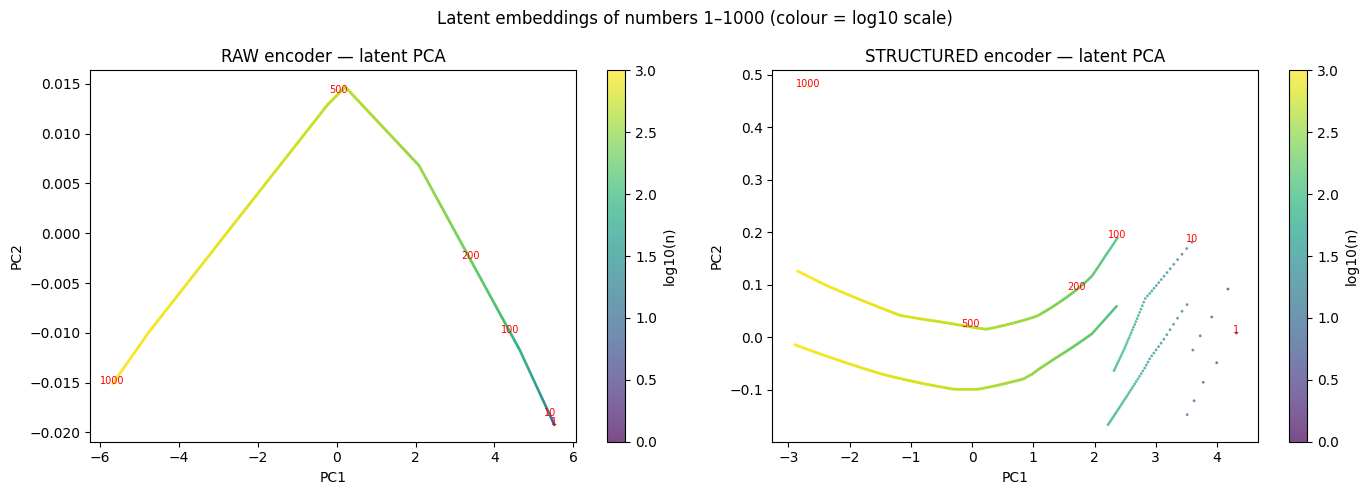


Multiplication geometry check (×10 steps in PCA space):
         n       10n     PC1 shift     PC2 shift
         1        10       -0.7256        0.1729
         5        50       -1.0599        0.1272
        10       100       -1.2183        0.0084
        50       500       -2.7437       -0.0216
       100      1000       -5.0484        0.2871


In [9]:
# ============================================================
# A6: Inspect latent space — does a number line emerge?
# ============================================================

ns = np.arange(1, 1001)
nt = torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(1)
nt_feats = structured_features(nt)

with torch.no_grad():
    emb_raw   = model_raw.embed(nt / TRAIN_MAX).cpu().numpy()
    emb_struc = model_struc.embed(nt_feats).cpu().numpy()

pca_raw   = PCA(n_components=2).fit_transform(emb_raw)
pca_struc = PCA(n_components=2).fit_transform(emb_struc)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pca, title in [
    (axes[0], pca_raw,   'RAW encoder — latent PCA'),
    (axes[1], pca_struc, 'STRUCTURED encoder — latent PCA'),
]:
    sc = ax.scatter(pca[:, 0], pca[:, 1], c=np.log10(ns), cmap='viridis',
                    s=4, alpha=0.7, edgecolors='none')
    for n_mark in [1, 10, 100, 200, 500, 1000]:
        idx = n_mark - 1
        ax.annotate(str(n_mark), (pca[idx, 0], pca[idx, 1]),
                    fontsize=7, color='red', ha='center')
    plt.colorbar(sc, ax=ax, label='log10(n)')
    ax.set_title(title)
    ax.set_xlabel('PC1'); ax.set_ylabel('PC2')

plt.suptitle('Latent embeddings of numbers 1–1000 (colour = log10 scale)')
plt.tight_layout()
plt.show()

# Check multiplication geometry: does ×10 correspond to consistent shift?
print('\nMultiplication geometry check (×10 steps in PCA space):')
print(f'  {"n":>8s}  {"10n":>8s}  {"PC1 shift":>12s}  {"PC2 shift":>12s}')
for n in [1, 5, 10, 50, 100]:
    if n * 10 <= 1000:
        shift = pca_struc[n*10-1] - pca_struc[n-1]
        print(f'  {n:>8d}  {n*10:>8d}  {shift[0]:>12.4f}  {shift[1]:>12.4f}')

---
## PART B — XWorld Shape Classes as Attractors Under Distortion

The analogy to Part A: arithmetic operations move numbers to new positions. Distortions move time series to new positions in the 6-feature space. The question: do shape classes behave like attractor basins — do mild distortions stay inside the basin, strong ones escape?

We generate canonical synthetic instances of all 8 shape classes, apply four distortion types at three strengths, and track how far each series drifts in feature space and whether it crosses into a different class region.

In [10]:
# ============================================================
# B1: XWorld helpers (same as previous notebooks)
# ============================================================

TARGET_LEN = 64
TIMEDOM_COLS = ['skewness', 'kurtosis', 'lag1_autocorr', 'zero_crossings', 'slope', 'baseline_delta']


def zscore_normalize(s):
    s = np.asarray(s, dtype=float)
    std = s.std()
    return (s - s.mean()) / std if std > 0 else s - s.mean()


def baseline_delta(series, frac=0.10):
    n = len(series)
    k = max(1, int(n * frac))
    return float(np.mean(series[-k:]) - np.mean(series[:k]))


def extract_features(series):
    arr = zscore_normalize(np.asarray(series, dtype=float))
    n, t = len(arr), np.arange(len(arr))
    lag1 = float(np.corrcoef(arr[:-1], arr[1:])[0, 1]) if n > 2 else 0.0
    return {
        'skewness':       float(stats.skew(arr)),
        'kurtosis':       float(stats.kurtosis(arr)),
        'lag1_autocorr':  lag1,
        'zero_crossings': float(np.sum(np.diff(np.sign(arr)) != 0) / n),
        'slope':          float(stats.linregress(t, arr).slope),
        'baseline_delta': baseline_delta(arr),
    }


print('Helpers loaded.')

Helpers loaded.


In [11]:
# ============================================================
# B2: Synthetic canonical instances — one per shape class
# Generate 50 instances per class with small natural variation
# ============================================================

N_INSTANCES = 50
n = TARGET_LEN
t = np.linspace(0, 1, n)


def gen_instances(generator_fn, n_instances, seed_offset=0):
    series_list = []
    for i in range(n_instances):
        rng_i = np.random.default_rng(42 + seed_offset + i)
        s = generator_fn(rng_i)
        series_list.append(zscore_normalize(s))
    return series_list


# 1. Burst event
def gen_burst(rng):
    peak = rng.uniform(0.2, 0.45)
    width = rng.uniform(0.07, 0.12)
    s = np.exp(-(t - peak)**2 / (2 * width**2))
    return s + rng.normal(0, 0.04, n)

# 2. Eco-cycle (predator-prey)
def gen_eco_cycle(rng):
    periods = rng.uniform(1.5, 2.5)
    freq = 2 * np.pi * periods
    s = np.sin(freq * t) + 0.4 * np.sin(2 * freq * t)
    return s + rng.normal(0, 0.12, n)

# 3. Oscillator (sunspot — smooth, symmetric)
def gen_oscillator(rng):
    periods = rng.uniform(2.0, 3.5)
    freq = 2 * np.pi * periods
    s = np.sin(freq * t)
    return s + rng.normal(0, 0.05, n)

# 4. Seasonal (keeling_seasonal — annual cycle, left-skewed shoulder)
def gen_seasonal(rng):
    freq = 2 * np.pi
    s = np.sin(freq * t) + 0.25 * np.sin(2 * freq * t)
    return s + rng.normal(0, 0.04, n)

# 5. Clean monotonic trend (keeling_trend, ch4)
def gen_trend(rng):
    s = t + 0.15 * t**2
    return s + rng.normal(0, 0.015, n)

# 6. Clean integrated trend (sea_level, ocean_heat — even smoother)
def gen_integrated_trend(rng):
    s = np.cumsum(np.ones(n) * 0.02 + rng.normal(0, 0.003, n))
    return s

# 7. Irregular asymmetric oscillator (VIX/ENSO — positive skew, irregular amplitude)
def gen_irregular_osc(rng):
    freq = 2 * np.pi * rng.uniform(2, 4)
    s = np.sin(freq * t) * (1 + 0.6 * rng.uniform(0, 1, n))
    s += rng.normal(0, 0.3, n)
    s = s + 0.3 * np.abs(s)  # positive asymmetry
    return s

# 8. Declining oscillator (arctic_sea_ice)
def gen_declining_osc(rng):
    periods = rng.uniform(3, 5)
    freq = 2 * np.pi * periods
    amplitude = np.linspace(1.0, 0.55, n)
    mean_shift = np.linspace(0.0, -0.6, n)
    s = amplitude * np.sin(freq * t) + mean_shift
    return s + rng.normal(0, 0.05, n)


SHAPE_CLASSES = {
    'burst':            gen_burst,
    'eco_cycle':        gen_eco_cycle,
    'oscillator':       gen_oscillator,
    'seasonal':         gen_seasonal,
    'trend':            gen_trend,
    'integrated_trend': gen_integrated_trend,
    'irregular_osc':    gen_irregular_osc,
    'declining_osc':    gen_declining_osc,
}

# Generate instances and extract features
records = []
raw_series_bank = {}

for cls_name, gen_fn in SHAPE_CLASSES.items():
    instances = gen_instances(gen_fn, N_INSTANCES, seed_offset=list(SHAPE_CLASSES).index(cls_name) * 1000)
    raw_series_bank[cls_name] = instances
    for i, s in enumerate(instances):
        feat = extract_features(s)
        feat['shape_class'] = cls_name
        feat['instance_id'] = i
        feat['distortion'] = 'none'
        feat['strength'] = 0.0
        records.append(feat)

df_base = pd.DataFrame(records)
print(f'Base dataset: {len(df_base)} instances across {len(SHAPE_CLASSES)} shape classes')
print()
print('Feature profile of canonical instances (mean per class):')
print(df_base.groupby('shape_class')[TIMEDOM_COLS].mean().round(3).to_string())

Base dataset: 400 instances across 8 shape classes

Feature profile of canonical instances (mean per class):
                  skewness  kurtosis  lag1_autocorr  zero_crossings  slope  baseline_delta
shape_class                                                                               
burst                1.177    -0.035          0.976           0.036 -0.021          -0.135
declining_osc        0.211    -1.124          0.923           0.119 -0.022          -1.975
eco_cycle           -0.162    -1.025          0.946           0.105 -0.010          -0.866
integrated_trend    -0.007    -1.199          1.000           0.016  0.054           3.139
irregular_osc        0.276    -1.128          0.832           0.127 -0.006          -0.756
oscillator          -0.151    -1.432          0.955           0.092 -0.006          -0.516
seasonal             0.000    -1.297          0.991           0.038 -0.045          -0.977
trend                0.090    -1.193          0.998           0.018  0.0

In [12]:
# ============================================================
# B3: Distortion operators
# ============================================================

def time_reverse(s, **kw):   return s[::-1].copy()
def amplitude_flip(s, **kw): return -s
def add_noise(s, sigma):     return s + np.random.default_rng(99).normal(0, sigma, len(s))
def time_warp(s, factor):
    n_orig = len(s)
    x_old  = np.linspace(0, 1, n_orig)
    x_new  = np.linspace(0, 1, max(2, int(n_orig * factor)))
    warped = np.interp(x_old, x_new, np.interp(x_new, x_old, s))
    return warped


DISTORTIONS = [
    ('time_reverse',    time_reverse,   [{'strength': 1.0}]),
    ('amplitude_flip',  amplitude_flip, [{'strength': 1.0}]),
    ('noise',           add_noise,      [{'sigma': 0.1, 'strength': 0.1},
                                         {'sigma': 0.3, 'strength': 0.3},
                                         {'sigma': 0.7, 'strength': 0.7}]),
    ('time_warp',       time_warp,      [{'factor': 0.7, 'strength': 0.3},
                                         {'factor': 1.4, 'strength': 0.4}]),
]


# Apply distortions and extract features
dist_records = []

for cls_name, instances in raw_series_bank.items():
    for inst_id, s_orig in enumerate(instances):
        for dist_name, dist_fn, param_list in DISTORTIONS:
            for params in param_list:
                strength = params.pop('strength')
                s_dist   = dist_fn(s_orig, **params)
                s_dist   = zscore_normalize(s_dist)
                params['strength'] = strength
                feat = extract_features(s_dist)
                feat['shape_class']  = cls_name
                feat['instance_id']  = inst_id
                feat['distortion']   = dist_name
                feat['strength']     = strength
                dist_records.append(feat)

df_dist = pd.DataFrame(dist_records)
print(f'Distorted instances: {len(df_dist)}')
print(f'Distortion types: {df_dist["distortion"].value_counts().to_dict()}')

Distorted instances: 2800
Distortion types: {'noise': 1200, 'time_warp': 800, 'amplitude_flip': 400, 'time_reverse': 400}


In [13]:
# ============================================================
# B4: Feature drift — how far does each distortion move a
#     series in the 6-feature space?
# ============================================================

sc = StandardScaler()
X_base = sc.fit_transform(df_base[TIMEDOM_COLS].values)

# Compute per-class centroids in standardised feature space
class_centroids = {}
for cls in SHAPE_CLASSES:
    mask = df_base['shape_class'] == cls
    class_centroids[cls] = X_base[mask].mean(axis=0)

# For each distorted series, measure L2 distance from its class centroid
X_dist = sc.transform(df_dist[TIMEDOM_COLS].values)

drift_records = []
for i, row in df_dist.iterrows():
    x_dist = X_dist[i - df_dist.index[0]]
    centroid = class_centroids[row['shape_class']]
    drift = float(np.linalg.norm(x_dist - centroid))
    drift_records.append({
        'shape_class': row['shape_class'],
        'distortion':  row['distortion'],
        'strength':    row['strength'],
        'drift':       drift,
    })

# Baseline drift (within class, no distortion)
baseline_drifts = {}
for cls in SHAPE_CLASSES:
    mask = df_base['shape_class'] == cls
    X_cls = X_base[mask]
    c = X_cls.mean(axis=0)
    baseline_drifts[cls] = float(np.linalg.norm(X_cls - c, axis=1).mean())

df_drift = pd.DataFrame(drift_records)

# Summary: mean drift per (distortion, class)
print('Feature drift from class centroid — mean L2 (standardised space)')
print('  Lower = more stable. Baseline = natural within-class spread.\n')

pivot = df_drift.pivot_table('drift', index='shape_class', columns='distortion', aggfunc='mean')
pivot['baseline'] = pd.Series(baseline_drifts)
print(pivot.round(3).to_string())

Feature drift from class centroid — mean L2 (standardised space)
  Lower = more stable. Baseline = natural within-class spread.

distortion        amplitude_flip  noise  time_reverse  time_warp  baseline
shape_class                                                               
burst                      5.934  3.611         1.885      1.305     1.304
declining_osc              2.726  2.675         2.533      0.643     0.637
eco_cycle                  1.546  2.807         1.299      0.944     0.806
integrated_trend           4.597  3.206         4.597      0.072     0.072
irregular_osc              1.889  2.885         1.344      1.741     1.035
oscillator                 1.144  2.797         0.846      0.618     0.615
seasonal                   2.864  2.924         2.864      0.250     0.325
trend                      4.614  3.194         4.593      0.073     0.096


In [14]:
# ============================================================
# B5: Class boundary crossing — does distortion change
#     the nearest-centroid class label?
# ============================================================

centroids_mat = np.stack([class_centroids[c] for c in SHAPE_CLASSES])
class_names   = list(SHAPE_CLASSES.keys())


def nearest_class(x_vec):
    dists = np.linalg.norm(centroids_mat - x_vec, axis=1)
    return class_names[dists.argmin()]


crossing_records = []
for i, row in df_dist.iterrows():
    x_dist = X_dist[i - df_dist.index[0]]
    predicted_cls = nearest_class(x_dist)
    crossing_records.append({
        'shape_class':    row['shape_class'],
        'distortion':     row['distortion'],
        'strength':       row['strength'],
        'predicted_class': predicted_cls,
        'boundary_crossed': predicted_cls != row['shape_class'],
    })

df_cross = pd.DataFrame(crossing_records)

print('Boundary crossing rate — fraction of instances reassigned to a different class')
print()
cross_pivot = df_cross.pivot_table('boundary_crossed', index='shape_class',
                                    columns='distortion', aggfunc='mean')
print(cross_pivot.round(3).to_string())
print()

# Which class does each mislabelled instance cross TO?
print('Most common crossing destinations (when boundary is crossed):')
crossed = df_cross[df_cross['boundary_crossed']]
if len(crossed) > 0:
    for cls in SHAPE_CLASSES:
        c = crossed[crossed['shape_class'] == cls]
        if len(c) == 0: continue
        dest = c['predicted_class'].value_counts().head(2)
        print(f'  {cls:20s} → {dest.to_dict()}')
else:
    print('  No boundary crossings detected.')

Boundary crossing rate — fraction of instances reassigned to a different class

distortion        amplitude_flip  noise  time_reverse  time_warp
shape_class                                                     
burst                       1.00  0.407          0.00       0.00
declining_osc               1.00  0.540          1.00       0.00
eco_cycle                   0.18  0.587          0.16       0.29
integrated_trend            1.00  0.693          1.00       0.04
irregular_osc               0.18  0.013          0.04       0.83
oscillator                  0.00  0.593          0.00       0.00
seasonal                    1.00  0.667          1.00       0.00
trend                       1.00  0.340          1.00       0.00

Most common crossing destinations (when boundary is crossed):
  burst                → {'irregular_osc': 50, 'eco_cycle': 49}
  eco_cycle            → {'irregular_osc': 64, 'oscillator': 33}
  oscillator           → {'irregular_osc': 64, 'eco_cycle': 13}
  seasonal    

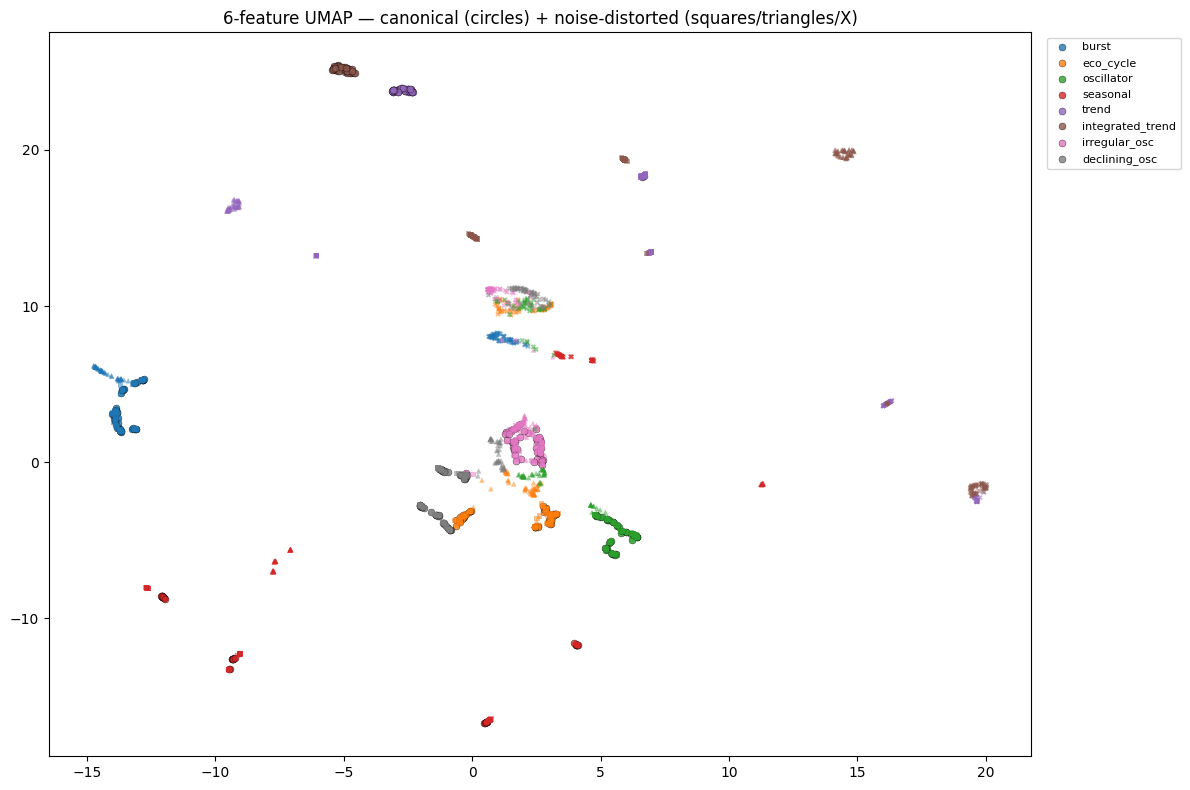

In [15]:
# ============================================================
# B6: UMAP — visualise base + distorted series in feature space
# ============================================================

# Combine base and distorted (pick one distortion for clarity)
df_vis_base = df_base[TIMEDOM_COLS + ['shape_class']].copy()
df_vis_base['distortion'] = 'none'

df_vis_dist = df_dist[df_dist['distortion'] == 'noise'].copy()
df_vis_dist = df_vis_dist[TIMEDOM_COLS + ['shape_class', 'distortion', 'strength']]

df_vis = pd.concat([df_vis_base, df_vis_dist], ignore_index=True)
X_vis  = sc.transform(df_vis[TIMEDOM_COLS].values)

reducer = umap.UMAP(n_neighbors=20, min_dist=0.1, random_state=42)
emb_vis = reducer.fit_transform(X_vis)

import seaborn as sns
palette = dict(zip(class_names, sns.color_palette('tab10', len(class_names))))
strength_markers = {'none': 'o', 0.1: 's', 0.3: '^', 0.7: 'X'}

fig, ax = plt.subplots(figsize=(12, 8))

n_base = len(df_vis_base)
for cls in class_names:
    mask = (df_vis['shape_class'] == cls) & (df_vis['distortion'] == 'none')
    ax.scatter(emb_vis[mask, 0], emb_vis[mask, 1],
               c=[palette[cls]], s=25, alpha=0.8, edgecolors='k', linewidths=0.3,
               marker='o', label=cls)

for strength, marker in [(0.1, 's'), (0.3, '^'), (0.7, 'X')]:
    mask = (df_vis['distortion'] == 'noise') & (df_vis.get('strength', None) == strength) \
           if 'strength' in df_vis.columns else np.zeros(len(df_vis), dtype=bool)
    for cls in class_names:
        m2 = mask & (df_vis['shape_class'] == cls)
        if m2.any():
            ax.scatter(emb_vis[m2, 0], emb_vis[m2, 1],
                       c=[palette[cls]], s=15, alpha=0.5, edgecolors='none', marker=marker)

ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
ax.set_title('6-feature UMAP — canonical (circles) + noise-distorted (squares/triangles/X)')
plt.tight_layout()
plt.show()

In [16]:
# ============================================================
# B7: Stability ranking — order shape classes by distortion
#     resistance across all distortion types
# ============================================================

# Normalise drift by baseline (intra-class spread)
df_drift['baseline'] = df_drift['shape_class'].map(baseline_drifts)
df_drift['relative_drift'] = df_drift['drift'] / df_drift['baseline'].clip(lower=0.01)

stability = df_drift.groupby('shape_class')['relative_drift'].mean().sort_values()

print('Shape class stability ranking (lower = more robust to distortion)')
print('  Relative drift = mean drift / intra-class spread\n')
for cls, val in stability.items():
    bar = '█' * int(val * 5)
    print(f'  {cls:22s}  {val:5.2f}  {bar}')

print()
# Crossing rate by class (overall)
cross_rate = df_cross.groupby('shape_class')['boundary_crossed'].mean().sort_values()
print('Boundary crossing rate (overall, any distortion):')
for cls, val in cross_rate.items():
    bar = '█' * int(val * 40)
    print(f'  {cls:22s}  {val:.3f}  {bar}')

Shape class stability ranking (lower = more robust to distortion)
  Relative drift = mean drift / intra-class spread

  irregular_osc            2.12  ██████████
  burst                    2.33  ███████████
  eco_cycle                2.33  ███████████
  oscillator               2.70  █████████████
  declining_osc            3.27  ████████████████
  seasonal                 6.60  ████████████████████████████████
  trend                   28.19  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████
  integrated_trend        37.50  ███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

Boundary crossing rate (overall, any distortion):
  oscillator              0.254  ██████████
  irregular_osc           0.274  ██████████
  burst                   0.317  ████████████
  eco

---
## Findings — Notebook 23

### Finding 53 (A): [Structured vs raw encoder — extrapolation]

**Prediction:** Structured 4D encoder (log + linear + parity + residue) extrapolates better than raw scalar encoder.

**Result:** *(run to find out)*

---

### Finding 54 (A): [Number line in latent PCA]

**Prediction:** PCA of structured encoder embeddings shows an ordered curve; ×10 steps are roughly uniform shifts in PC space.

**Result:** *(run to find out)*

---

### Finding 55 (B): [Shape class stability under distortion]

**Prediction:** Trend classes (clean monotonic, integrated trend) are most stable; burst and irregular oscillator most sensitive. Stability order: trend ≈ seasonal > oscillator > eco-cycle > declining osc > irregular osc > burst.

**Result:** *(run to find out)*

---

### Finding 56 (B): [Time-reversal and amplitude-flip — boundary crossings]

**Prediction:** Time-reversal causes zero crossings for symmetric classes (oscillator, seasonal, trend), causes crossings for declining oscillator (slope reversal) and burst (skewness sign flip). Amplitude-flip causes crossings only for burst and integrated trend (where sign of skewness/slope is the defining feature).

**Result:** *(run to find out)*

---

### Finding 57 (B): [Noise threshold for class escape]

**Prediction:** σ=0.1 preserves all classes. σ=0.3 escapes burst and irregular oscillator. σ=0.7 causes widespread crossing. The noise threshold for class escape is the XWorld equivalent of the arithmetic extrapolation boundary — the edge of the attractor basin.

**Result:** *(run to find out)*